# Global Superstore Sales Performance Analysis & Revenue Forecasting

## Project Objective

The objective of this project is to analyze the Global Superstore sales data to identify business trends, customer purchasing behavior, profitability, and sales performance across different regions. The project also develops machine learning models to forecast future sales and provides business recommendations through an interactive Power BI dashboard.

# 1. Import Required Libraries

In [1]:
!pip install openpyxl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 2. Load the Dataset

In [2]:
df = pd.read_excel("Global Superstore.xlsx")

df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,è®°å½•æ•°,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.shape

(51290, 27)

In [4]:
df.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'è®°å½•æ•°', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [5]:
df.info

<bound method DataFrame.info of               Category         City        Country Customer ID  \
0      Office Supplies  Los Angeles  United States   LS-172304   
1      Office Supplies  Los Angeles  United States   MV-174854   
2      Office Supplies  Los Angeles  United States   CS-121304   
3      Office Supplies  Los Angeles  United States   CS-121304   
4      Office Supplies  Los Angeles  United States   AP-109154   
...                ...          ...            ...         ...   
51285  Office Supplies  Los Angeles  United States   AM-103604   
51286  Office Supplies  Los Angeles  United States   AM-103604   
51287  Office Supplies  Los Angeles  United States   HR-147704   
51288  Office Supplies  Los Angeles  United States   RM-196754   
51289  Office Supplies  Los Angeles  United States   FH-143654   

          Customer Name  Discount Market  è®°å½•æ•° Order Date  \
0      Lycoris Saunders       0.0     US          1 2011-01-07   
1         Mark Van Huff       0.0     US   

In [6]:
df.describe

<bound method NDFrame.describe of               Category         City        Country Customer ID  \
0      Office Supplies  Los Angeles  United States   LS-172304   
1      Office Supplies  Los Angeles  United States   MV-174854   
2      Office Supplies  Los Angeles  United States   CS-121304   
3      Office Supplies  Los Angeles  United States   CS-121304   
4      Office Supplies  Los Angeles  United States   AP-109154   
...                ...          ...            ...         ...   
51285  Office Supplies  Los Angeles  United States   AM-103604   
51286  Office Supplies  Los Angeles  United States   AM-103604   
51287  Office Supplies  Los Angeles  United States   HR-147704   
51288  Office Supplies  Los Angeles  United States   RM-196754   
51289  Office Supplies  Los Angeles  United States   FH-143654   

          Customer Name  Discount Market  è®°å½•æ•° Order Date  \
0      Lycoris Saunders       0.0     US          1 2011-01-07   
1         Mark Van Huff       0.0     US 

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Unique Customers:", df["Customer ID"].nunique())

print("Unique Products:", df["Product ID"].nunique())

print("Countries:", df["Country"].nunique())

print("Categories:", df["Category"].nunique())

print("Sub-Categories:", df["Sub-Category"].nunique())

print("Markets:", df["Market"].nunique())

Rows: 51290
Columns: 27
Unique Customers: 4873
Unique Products: 10292
Countries: 147
Categories: 3
Sub-Categories: 17
Markets: 7


# 3. Data Cleaning & Preprocessing

In this section, we inspect the dataset for missing values, duplicate records, incorrect data types, and inconsistent entries. Clean data improves the accuracy of analysis and predictive models.

In [8]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
è®°å½•æ•°         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.dtypes

Category                  object
City                      object
Country                   object
Customer ID               object
Customer Name             object
Discount                 float64
Market                    object
è®°å½•æ•°                  int64
Order Date        datetime64[ns]
Order ID                  object
Order Priority            object
Product ID                object
Product Name              object
Profit                   float64
Quantity                   int64
Region                    object
Row ID                     int64
Sales                      int64
Segment                   object
Ship Date         datetime64[ns]
Ship Mode                 object
Shipping Cost            float64
State                     object
Sub-Category              object
Year                       int64
Market2                   object
weeknum                    int64
dtype: object

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [12]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [13]:
df.describe()

,Discount,è®°å½•æ•°,Order Date,Profit,Quantity,Row ID,Sales,Ship Date,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290,51290.000000,51290.000000,51290.00000,51290.000000,51290,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,2013-05-11 21:26:49.155780864,28.610982,3.476545,25645.50000,246.498440,2013-05-15 20:42:42.745174784,26.375818,2012.777208,31.287112
min,0.000000,1.0,2011-01-01 00:00:00,-6599.978000,1.000000,1.00000,0.000000,2011-01-03 00:00:00,0.002000,2011.000000,1.000000
25%,0.000000,1.0,2012-06-19 00:00:00,0.000000,2.000000,12823.25000,31.000000,2012-06-23 00:00:00,2.610000,2012.000000,20.000000
50%,0.000000,1.0,2013-07-08 00:00:00,9.240000,3.000000,25645.50000,85.000000,2013-07-12 00:00:00,7.790000,2013.000000,33.000000
75%,0.200000,1.0,2014-05-22 00:00:00,36.810000,5.000000,38467.75000,251.000000,2014-05-26 00:00:00,24.450000,2014.000000,44.000000
max,0.850000,1.0,2014-12-31 00:00:00,8399.976000,14.000000,51290.00000,22638.000000,2015-01-07 00:00:00,933.570000,2014.000000,53.000000
std,0.212280,0.0,NaN,174.340972,2.278766,14806.29199,487.567175,NaN,57.296810,1.098931,14.429795


In [14]:
print(df["Category"].unique())
print(df["Segment"].unique())
print(df["Market"].unique())
print(df["Ship Mode"].unique())

['Office Supplies' 'Technology' 'Furniture']
['Consumer' 'Home Office' 'Corporate']
['US' 'EU' 'LATAM' 'Africa' 'APAC' 'EMEA' 'Canada']
['Second Class' 'Standard Class' 'Same Day' 'First Class']


In [15]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [16]:
df[["Order Date", "Year", "Month", "Month Name"]].head()

,Order Date,Year,Month,Month Name
0,2011-01-07,2011,1,January
1,2011-01-21,2011,1,January
2,2011-08-05,2011,8,August
3,2011-08-05,2011,8,August
4,2011-09-29,2011,9,September


In [17]:
print(df["Order Date"].head(10))

0   2011-01-07
1   2011-01-21
2   2011-08-05
3   2011-08-05
4   2011-09-29
5   2011-10-19
6   2011-11-04
7   2011-11-12
8   2011-11-22
9   2011-12-05
Name: Order Date, dtype: datetime64[ns]


In [18]:
print(df["Order Date"].dt.year.value_counts())

Order Date
2014    17531
2013    13799
2012    10962
2011     8998
Name: count, dtype: int64


# 4. Exploratory Data Analysis (EDA)

This section explores sales, profit, customer behavior, regional performance, and product performance using visualizations. The goal is to identify key business trends and generate actionable insights.

## Overall Business Performance

This section summarizes the key business metrics of the Global Superstore dataset.

In [19]:
# Overall Business KPIs

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["Product ID"].nunique()

average_order_value = total_sales / total_orders

print(f"Total Sales           : ${total_sales:,.2f}")
print(f"Total Profit          : ${total_profit:,.2f}")
print(f"Total Orders          : {total_orders}")
print(f"Total Customers       : {total_customers}")
print(f"Total Products        : {total_products}")
print(f"Average Order Value   : ${average_order_value:,.2f}")

Total Sales           : $12,642,905.00
Total Profit          : $1,467,457.29
Total Orders          : 25035
Total Customers       : 4873
Total Products        : 10292
Average Order Value   : $505.01


### Business Insight

- The company generated $12,642,905 in total sales.
.Overall profit reached $1,467,457.29
- The business served **4873** across multiple markets.
- The average order value indicates customers spend approximately **$505.01** per order.

## Sales Distribution

Understanding the distribution of sales helps identify outliers and the overall sales pattern.

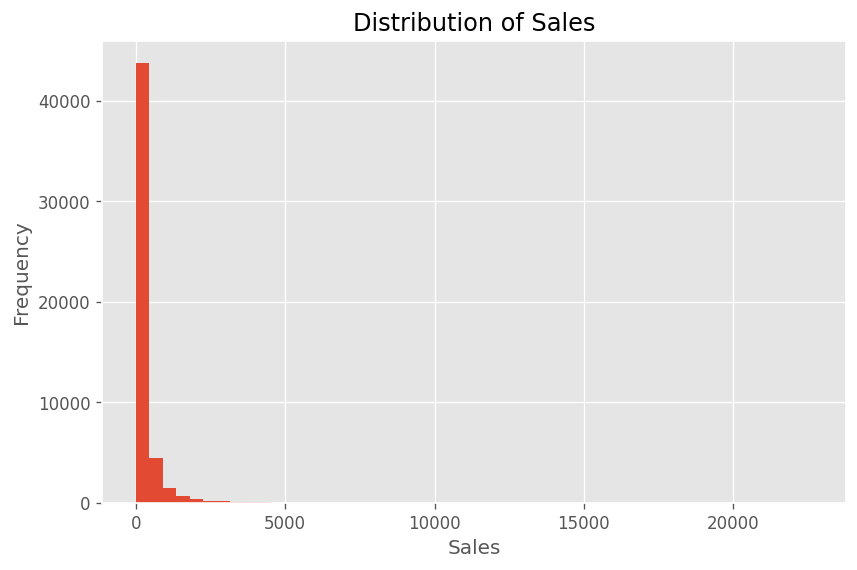

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=50)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## Profit Distribution

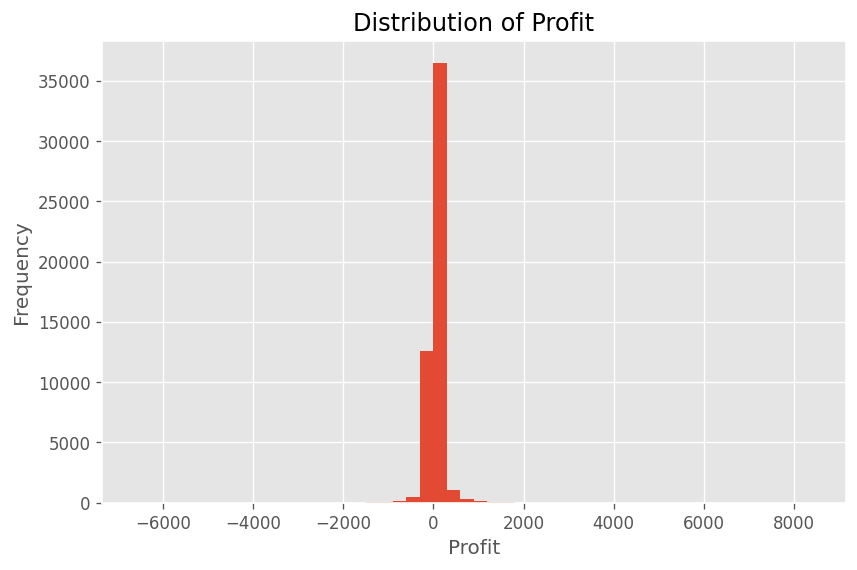

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["Profit"], bins=50)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

## Sales by Category

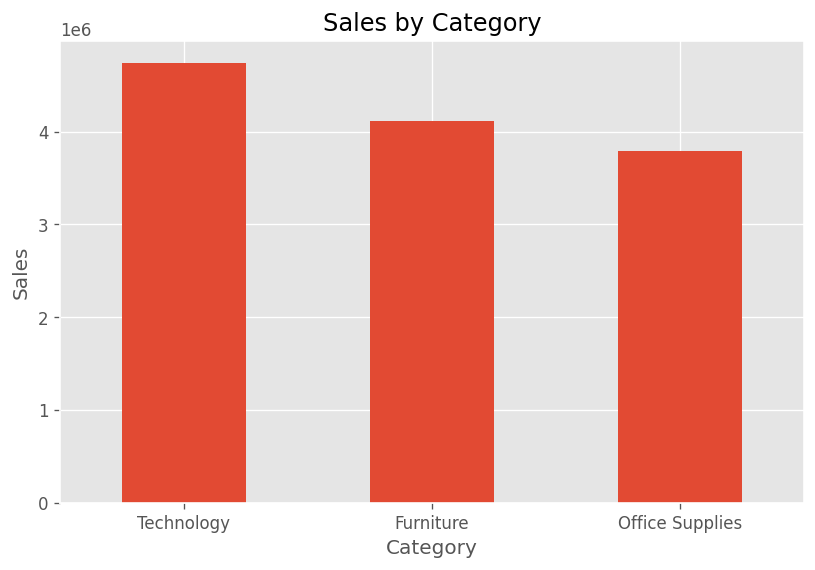

In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

## Profit by Category

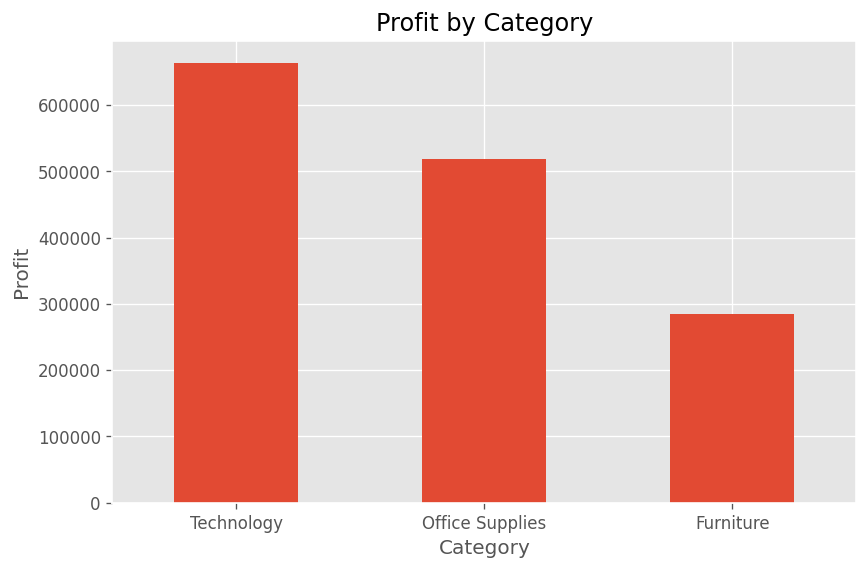

In [23]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

# Sales Trend Analysis

This section analyzes how sales have changed over time to identify seasonal patterns, growth trends, and fluctuations.

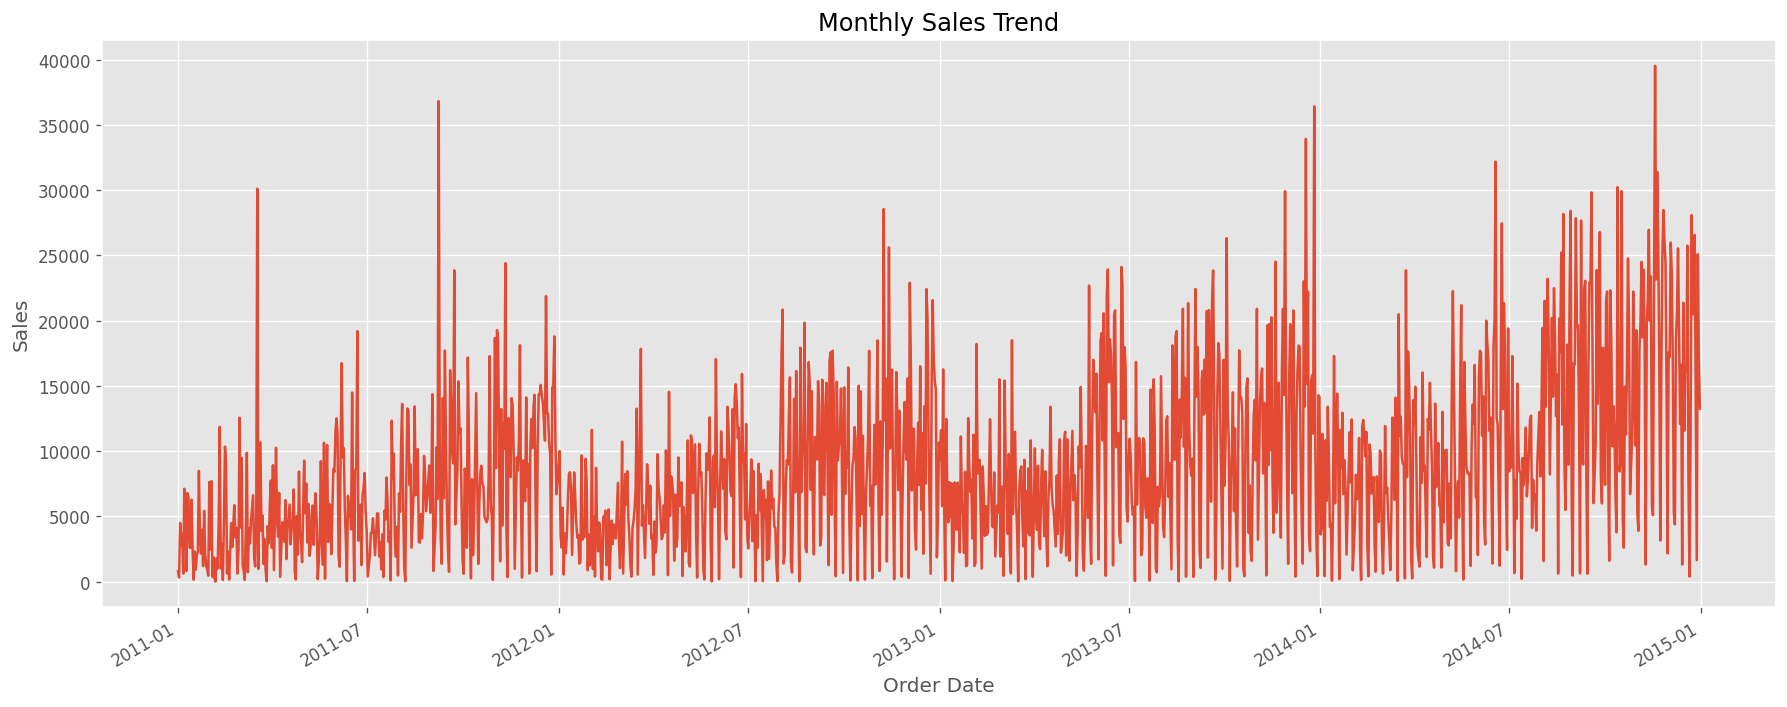

In [25]:
monthly_sales = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(15,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()

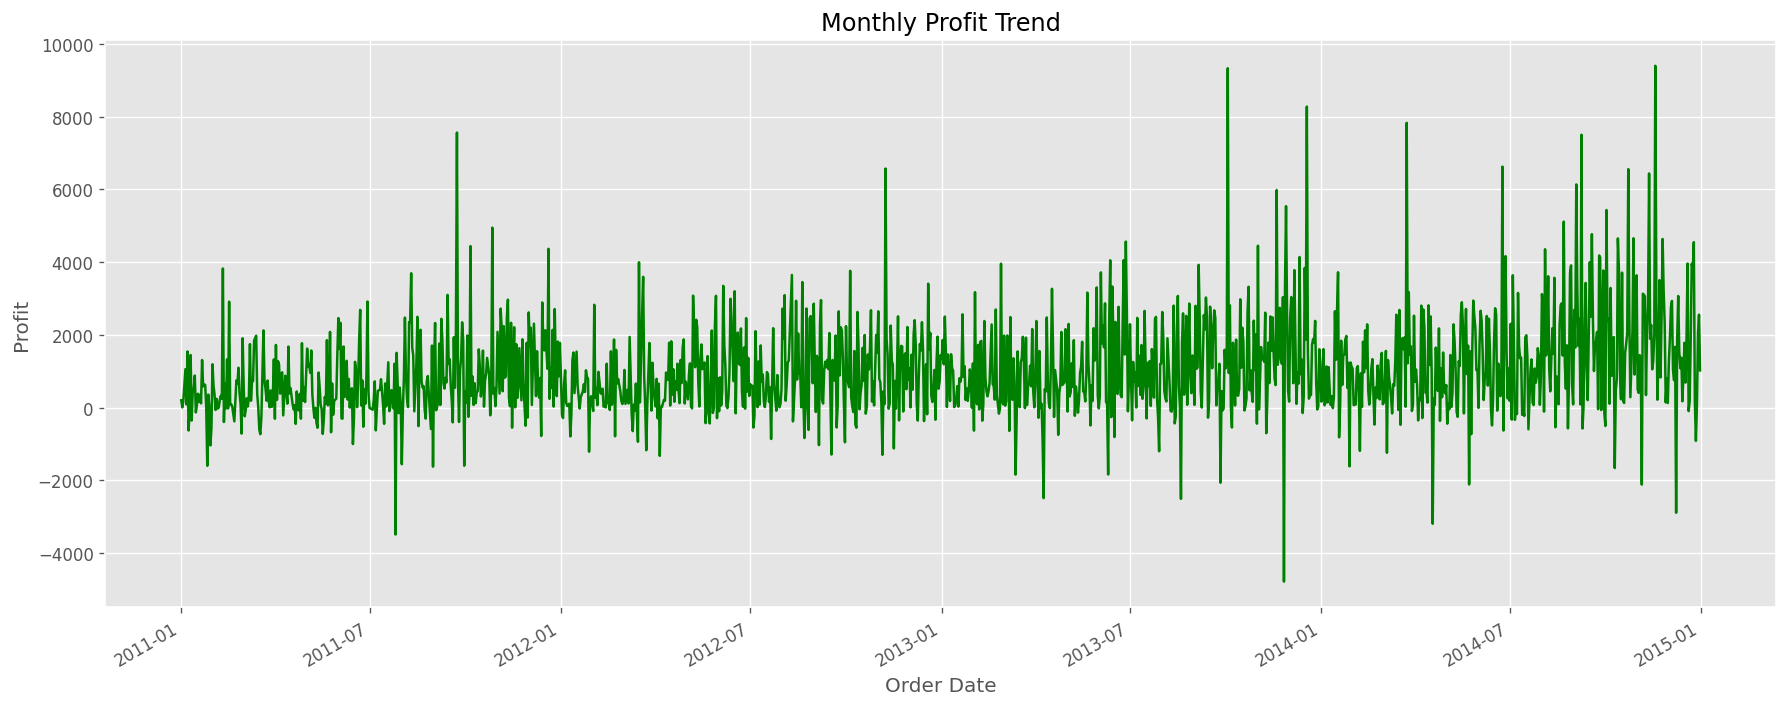

In [27]:
monthly_profit = df.groupby("Order Date")["Profit"].sum()

plt.figure(figsize=(15,6))
monthly_profit.plot(color="green")

plt.title("Monthly Profit Trend")
plt.xlabel("Order Date")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("monthly_profit_trend.png", dpi=300)
plt.show()

# Top Performing Products

Identify the products generating the highest sales.

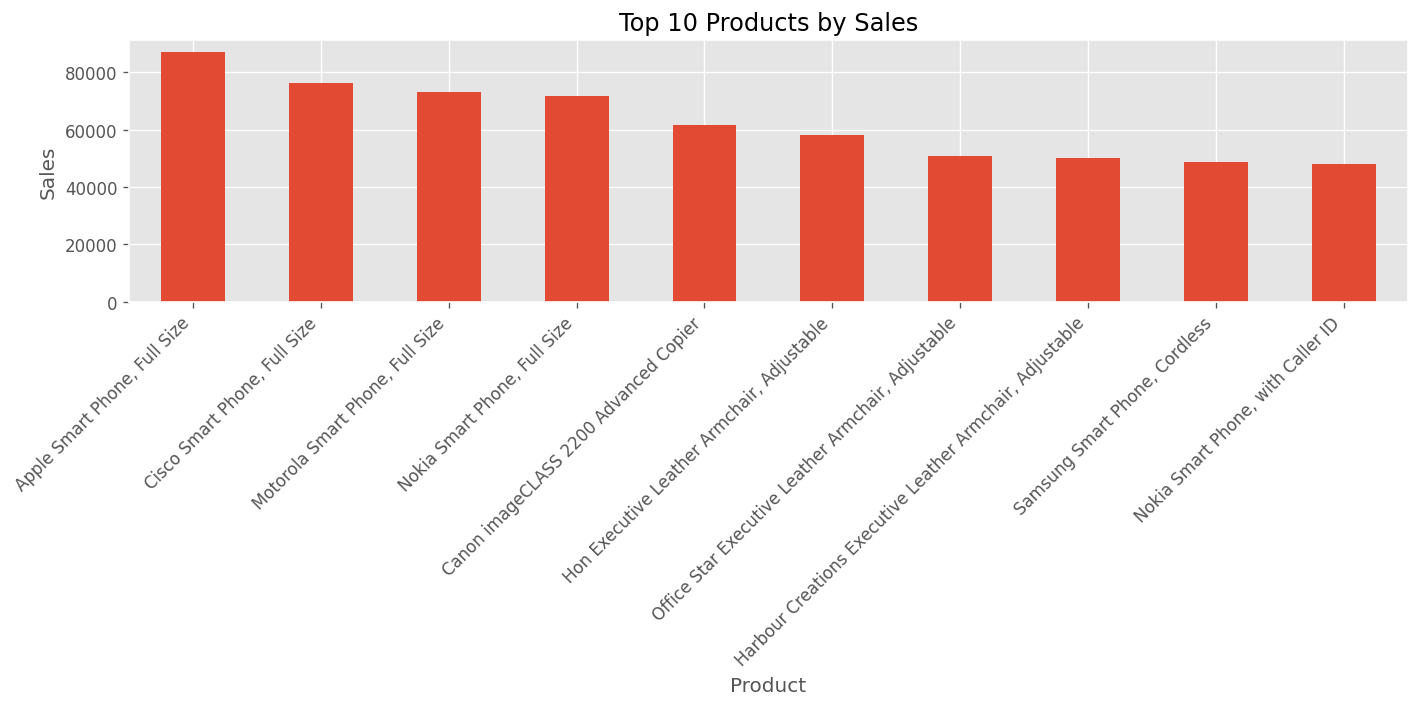

In [28]:
top_products = df.groupby("Product Name")["Sales"]\
                 .sum()\
                 .sort_values(ascending=False)\
                 .head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("top10_products.png", dpi=300)

plt.show()

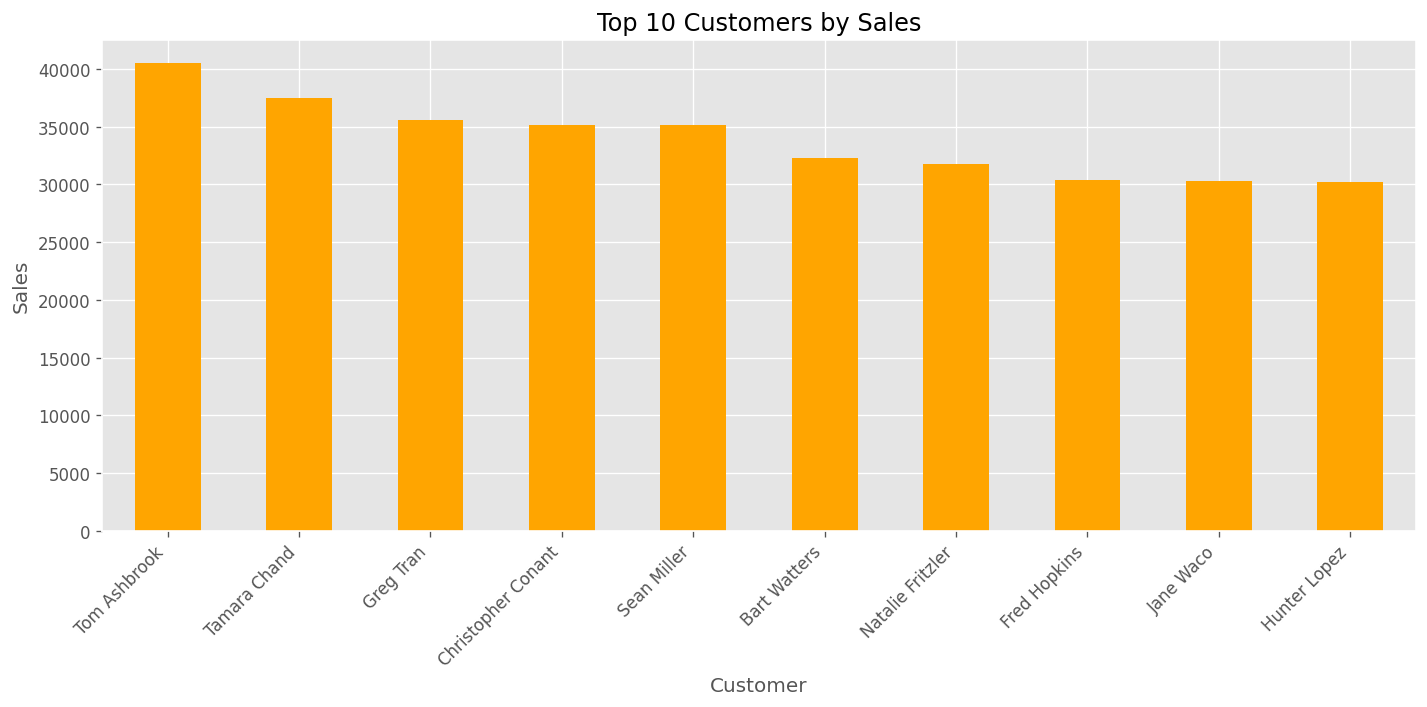

In [29]:
top_customers = df.groupby("Customer Name")["Sales"]\
                  .sum()\
                  .sort_values(ascending=False)\
                  .head(10)

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar", color="orange")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("top10_customers.png", dpi=300)

plt.show()

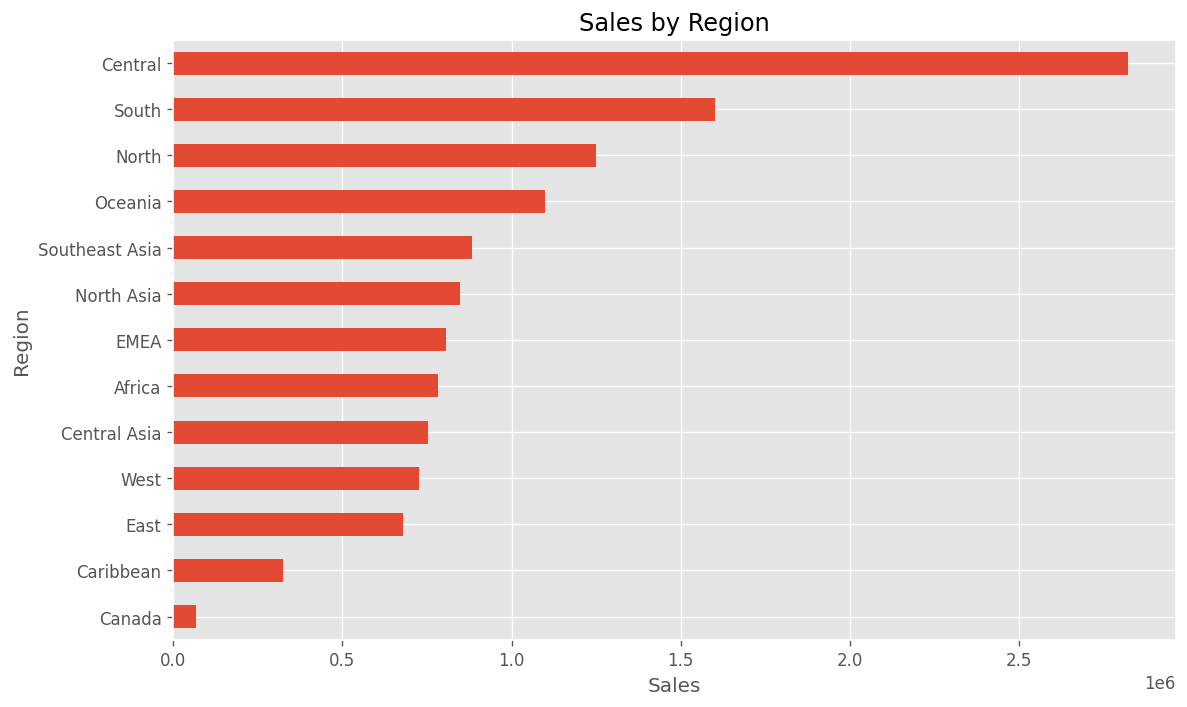

In [30]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

region_sales.plot(kind="barh")

plt.title("Sales by Region")
plt.xlabel("Sales")

plt.tight_layout()
plt.savefig("sales_region.png", dpi=300)

plt.show()

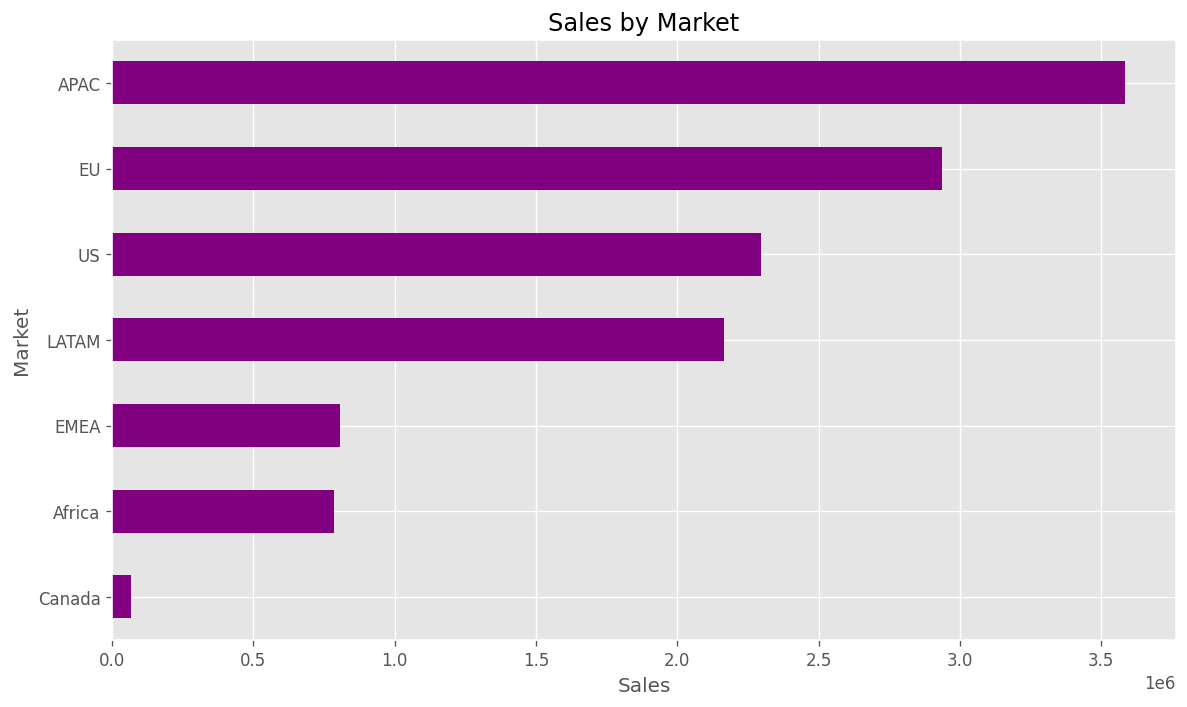

In [31]:
market_sales = df.groupby("Market")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

market_sales.plot(kind="barh", color="purple")

plt.title("Sales by Market")
plt.xlabel("Sales")

plt.tight_layout()
plt.savefig("sales_market.png", dpi=300)

plt.show()